In [4]:
import daemonflux # Flux estimation.
import numpy as np # Array handling.
import pandas as pd # Data handling.
from scipy import optimize # Fitting.
import matplotlib.pyplot as plt # Plotting.
from copy import deepcopy # Misc.

In [5]:
# Load the data files.
PATH = "fitting deepcore/"
DSETS = [
    "data",                                               # Data.
    "mc_nu_nc", "mc_nue_cc", "mc_numu_cc", "mc_nutau_cc", # MC neutrinos.
    "mc_mu",                                              # MC muons.
    "hs_nu_nc_nue_cc", "hs_numu_cc", "hs_nutau_cc"        # Hypersurfaces.
]
dfs = {dataset: pd.read_csv(PATH + dataset + ".csv") for dataset in DSETS}

# Combine MC neutrino sets.
dfs["mc_nu"] = pd.DataFrame()
for k, df in [(k, v) for k, v in dfs.items() if "mc_nu" in k and k != "mc_nu"]:
    dfs["mc_nu"] = pd.concat([dfs["mc_nu"], df], axis=0, ignore_index=True)
    del dfs[k]

# Create quick references to dict entries.
data, mcnu, mcmu = dfs["data"], dfs["mc_nu"], dfs["mc_mu"]
dhs = {k: df for k, df in dfs.items() if "hs" in k}

In [6]:
# Setup binning from the readme.
EN_MIN, EN_MAX = 6.31, 158.49
CZ_MIN, CZ_MAX = -1., .1

BINS = {
    "reco_energy" : np.logspace(np.log10(EN_MIN), np.log10(EN_MAX), num=12),
    "reco_coszen" : np.linspace(CZ_MIN, CZ_MAX, num=11),
    "pid"         : np.array([0.55, 0.75, 1.00]),
}

# Last energy bin has double size to contain sufficient statistics.
BINS["reco_energy"] = np.delete(BINS["reco_energy"], -2)

# Get neutrino count from data.
NUCOUNT = sum(data["count"])

In [7]:
# Downsize input MC data for expediency.
SCALING_FACTOR = 10
mcnu = mcnu.iloc[::SCALING_FACTOR, :].reset_index(drop=True)

# Normalize weights after scaling.
mcnu["weight"] *= SCALING_FACTOR

In [8]:
# Get flux using daemonflux (see https://github.com/mceq-project/daemonflux).
FLAVOR_FLUX = ("nue", "numu")
dflux = daemonflux.Flux(location = "generic")

# Store nu flux in corresponding arrays.
flux = {}
for fl in FLAVOR_FLUX:
    flux[fl] = np.zeros_like(mcnu["weight"])

print("Progress:")
for ei in range(len(mcnu)):
    # Check if nu or antinu.
    prefix = ""
    if mcnu["pdg"][ei] < 0: prefix = "anti"

    # Get zenith angle in degrees, from -90 to 90.
    zen = np.rad2deg(np.arccos(mcnu["true_coszen"][ei]))
    if zen > 90: zen = 180-zen

    # Get flux.
    for fl in FLAVOR_FLUX:
        flux[fl][ei] = dflux.flux([mcnu["true_energy"][ei]], zen, prefix+fl)

    # Print progress.
    if ei % 1e4 == 0: print("%6d | %6d" % (ei, len(mcnu)))
print("Done!")

# Correct flux -- daemonflux reports E^3 * flux in [GeV^-4 m^-2 s^-1 sr^-1], our
#     weight is in [GeV cm^2 sr].
for fl in FLAVOR_FLUX:
    flux[fl] *= 1e4 # m^2 -> cm^2.
    mcnu[fl + "_flux"] = flux[fl] / pow(mcnu["true_energy"], 3) # GeV^-4 -> -1.

Progress:
     0 |  39685
 10000 |  39685
 20000 |  39685
 30000 |  39685
Done!


In [9]:
# Constants to associate zenith angle with distance.
L1 = 19.
R  = 6378.2 + L1
def zen_to_d(coszen: float) -> float:
    """
    Converts the cosine of the zenith angle into distance.

    Args:
        coszen  : cosine of the zenith angle of the event.
        returns : event's distance in meters.
    """
    zen = np.arccos(coszen)
    phi = np.arcsin((1-L1/R) * np.sin(zen))
    psi = zen - phi
    return np.sqrt((R-L1)**2 + R**2 - (2*(R-L1) * R * np.cos(psi)))

In [10]:
# Define functions to obtain oscillated flux, so that we can later fit.
TAGS = {
    "nue"   : mcnu["pdg"] % 12 == 0,
    "numu"  : mcnu["pdg"] % 14 == 0,
    "nutau" : mcnu["pdg"] % 16 == 0,
}

def osc_flux(mcnu: pd.DataFrame, amp: float, dm31: float) -> list[float]:
    """
    Computes neutrino transition probability using the 2-flavor approximation,
    returning an oscillated flux array that takes muon neutrino disappearance
    and tau neutrino appearance into account.

    Args:
        mcnu    : pandas dataframe with MC neutrinos.
        amp     : real value for the sin2(2 * theta23) in the 2-flavor approx-
                  imation.
        dm31    : neutrino mass splitting in eV^2.
        returns : array with the oscillated flux.
    """
    baseline = zen_to_d(mcnu["true_coszen"]) / mcnu["true_energy"]
    ptau = amp * np.sin(1.267 * dm31 * baseline)**2
    pmu  = 1 - ptau

    # Compute oscillated flux.
    oflux = np.zeros_like(mcnu["weight"])

    oflux[TAGS["nue"]]   = deepcopy(mcnu["nue_flux"][TAGS["nue"]])
    oflux[TAGS["numu"]]  = mcnu["numu_flux"][TAGS["numu"]] *pmu[TAGS["numu"]]
    oflux[TAGS["nutau"]] = mcnu["numu_flux"][TAGS["nutau"]]*ptau[TAGS["nutau"]]
    
    return oflux

In [11]:
# Setup hypersurfaces parameters.
NOMINAL_SYSTEMATICS = { # From readme.
    "dom_eff"          :  1.00,
    "hole_ice_p0"      :  0.10,
    "hole_ice_p1"      : -0.05,
    "bulk_ice_abs"     :  1.00,
    "bulk_ice_scatter" :  1.00,
}

def get_corr_factors(hs: pd.DataFrame, fit: dict[str, float]) -> pd.Series:
    """
    Computes the hypersurfaces correction factors for a given fit.

    Args:
        hs      : pandas dataframe with the binned hypersurfaces gradients.
        fit     : detector systematics to be tested.
        returns : array hypersurfaces correction for each bin.
    """
    # Compute difference between fit and nominal.
    diff = {k: v - NOMINAL_SYSTEMATICS[k] for k, v in fit.items()}
    return hs["intercept"] + sum([hs[k] * v for k, v in diff.items()])

In [12]:
HIST_SHAPE = tuple(map(lambda v: len(v)-1, [v for v in BINS.values()]))
def make_mcnu_hist(
    mcnu: pd.DataFrame, dhs: dict[str, pd.DataFrame] = None, dm31: float = None,
    fit: dict[str, float] = None
) -> np.ndarray[HIST_SHAPE, float]:
    """
    Makes four histograms from MC neutrino dataframe (nu_nc, nue_cc, numu_cc,
    nutau_cc), applies hypersurfaces corrections to each, and returns the sum of
    each histogram.

    Args:
        mcnu    : pandas dataframe with the MC neutrinos.
        dhs     : dictionary with hypersurface for each dm31 value.
        dm31    : mass splitting value to be tested.
        fit     : detector systematics to be tested.
        returns : histogram with the corrected MC neutrinos.
    """

    # Assert that dm31 is within the hypersurfaces interpolation range.
    dm31bins = dhs["hs_numu_cc"]["deltam31"].unique()
    if dm31 < dm31bins.min() or dm31bins.max() < dm31:
        raise ValueError("dm31 of %f is outside of interpolation range." % dm31)

    # Get dm31 bin length.
    binlen = dm31bins[1] - dm31bins[0]

    # Separate MC nu dataframe.
    mc = {
        "nu_nc"    : mcnu[(mcnu["type"] == 0)],
        "nue_cc"   : mcnu[(mcnu["type"] != 0) & (abs(mcnu["pdg"]) == 12)],
        "numu_cc"  : mcnu[(mcnu["type"] != 0) & (abs(mcnu["pdg"]) == 14)],
        "nutau_cc" : mcnu[(mcnu["type"] != 0) & (abs(mcnu["pdg"]) == 16)],
    }
    # Prepare sum of histograms.
    hist_total, _ = np.histogramdd([[], [], []], bins = list(BINS.values()))

    # Iterate through neutrino flavors.
    for flavor, df in mc.items():
        # Make MC histogram.
        hist, _ = np.histogramdd(
            [df["reco_energy"], df["reco_coszen"], df["pid"]],
            weights = NUCOUNT * df["osc_flux"] * df["weight"],
            bins = list(BINS.values())
        )

        # Apply hypersurfaces correction.
        if all(par is not None for par in [dhs, dm31, fit]):
            # Get the right HS entry.
            hs = [df for key, df in dhs.items() if flavor in key][0]

            # Get hypersurface below and above dm31.
            hs_lower = hs.loc[
                (dm31 - binlen < hs["deltam31"]) & (hs["deltam31"] < dm31)
            ].reset_index()
            hs_upper = hs.loc[
                (dm31 < hs["deltam31"]) & (hs["deltam31"] < dm31 + binlen)
            ].reset_index()

            # Create the interpolated hypersurface.
            hs_int = hs_lower.copy()
            for p in fit.keys():
                grad = (np.array(hs_upper[p]) - np.array(hs_lower[p])) / binlen
                hs_int[p] = grad * (dm31 - hs_lower["deltam31"][0]) + hs_lower[p]

            # Compute the correction factors.
            corr_factors = get_corr_factors(hs_int, fit)
            
            # Make the HS correction histogram.
            hs_corr, _ = np.histogramdd(
                [hs_int["reco_energy"], hs_int["reco_coszen"], hs_int["pid"]],
                weights = corr_factors, bins = list(BINS.values())
            )

            # Apply HS correction.
            hist *= hs_corr

        # Add corrected histogram to total.
        hist_total += hist

    # Return sum of MC neutrino histograms.
    return hist_total

In [13]:
BESTFIT_SYSTEMATICS = { # From Table IV in the paper.
    "dom_eff"          :  1.06,
    "hole_ice_p0"      : -0.27,
    "hole_ice_p1"      : -0.04,
    "bulk_ice_abs"     :  0.97,
    "bulk_ice_scatter" :  0.99,
}


In [14]:
# Data histogram - we won't change this.
h_data, _ = np.histogramdd(
    [data["reco_energy"], data["reco_coszen"], data["pid"]],
    bins = list(BINS.values()), weights = data["count"]
)
# Prepare some test parameters for the oscillated flux.
TEST_AMP    = 1.
TEST_DM31   = 2.41e-3
TEST_MUFRAC = 0.05
mcnu["osc_flux"] = osc_flux(mcnu, TEST_AMP, TEST_DM31)
# MC neutrino histogram with systematics in best fit.
h_mcnu = make_mcnu_hist(mcnu, dhs, TEST_DM31, BESTFIT_SYSTEMATICS)

# MC muon histogram - in this example, we won't change the shape of the muon
#     template, but the overall muon rate is scaled via a normalization factor.
#     This corresponds to the "Atmospheric muon scale" systematic in the paper.
#     The best fit value in the paper is 1.39 for this parameter, but we keep it
#     free in this simple fit.
h_mcmu, _ = np.histogramdd(
    [mcmu["reco_energy"], mcmu["reco_coszen"], mcmu["pid"]],
    bins = list(BINS.values()), weights = mcmu["count"]
)

In [15]:
def eval_weights(
    mcnu: pd.DataFrame,
    h_data: np.ndarray[HIST_SHAPE, float],
    h_mcmu: np.ndarray[HIST_SHAPE, float],
    dhs: dict[str, pd.DataFrame],
    amp: float, dm31: float, mu_frac: float
) -> tuple[np.ndarray[HIST_SHAPE, float], np.ndarray[HIST_SHAPE, float]]:
    """
    Makes the MC neutrino histogram re-evaluating the weights based on an oscil-
    lated flux evaluated from physics parameters. Then, returns both the MC neu-
    trino and MC muon histograms rescaled by a global factor.

    Args:
        mcnu    : pandas dataframe with MC neutrino data.
        h_data  : numpy array with 3D data histogram.
        h_mcmu  : numpy array with 3D MC muon histogram.
        dhs     : dictionary with hypersurface for each dm31 value.
        amp     : real value for the sin2(2 * theta23) in the 2-flavor approx-
                  imation.
        dm31    : neutrino mass splitting in eV^2.
        mu_frac : fraction of the sample composed of atmospheric muon back-
                  ground.
        returns : MC neutrino and muon histograms, scaled by mu_frac.
    """
    # Get oscillated weight.
    mcnu["osc_flux"] = osc_flux(mcnu, amp, dm31)

    # Make the MC neutrino histogram.
    h_mcnu = make_mcnu_hist(mcnu, dhs, dm31, BESTFIT_SYSTEMATICS)
    
    # Scale the number of nu events to match the data.
    nu_scale = h_data.sum() * (1 - mu_frac) / h_mcnu.sum()
    mu_scale = h_data.sum() * mu_frac       / h_mcmu.sum()

    return nu_scale * h_mcnu, mu_scale * h_mcmu

In [16]:
def chi2(params: list[float]) -> float:
    """
    Calculates a simplified chi2. For simplicity, this function assumes that
    `mcnu`, `h_data`, and `h_mcmu` are defined outside the scope of this func-
    tion.

    Args:
        params  : list containing the amplitude, dm31, and muon fraction.
        returns : the calculated chi2.
    """
    amp     = params[0]
    dm31    = params[1]
    mu_frac = params[2]

    # Get MC histogram.
    h_mcnu_s, h_mcmu_s = eval_weights(
        mcnu, h_data, h_mcmu, dhs, amp, dm31, mu_frac
    )
    mc_total = h_mcnu_s + h_mcmu_s

    # Compute and return chi2.
    chi2 = (h_data - mc_total)**2 / mc_total
    chi2[np.isnan(chi2)] = 0.
    return chi2.sum() #/ (len(params) * np.sqrt(np.sum(h_data)))

In [17]:
n_bins_energy = len(BINS["reco_energy"]) - 1
n_bins_coszen  = len(BINS["reco_coszen"]) - 1
n_bins_pid     = len(BINS["pid"]) - 1

N_bins = n_bins_energy * n_bins_coszen * n_bins_pid

In [18]:
dm31_bins = dhs["hs_numu_cc"]["deltam31"].unique()
BOUNDS = [
    (0.75,1.2), (dm31_bins.min() + 1e-4, dm31_bins.max() - 1e-4), (0., 1.)
]

result = optimize.minimize(
    chi2, [TEST_AMP, TEST_DM31, TEST_MUFRAC], method="L-BFGS-B", bounds=BOUNDS
)
print("amp      = %f" % result.x[0])
print("dm31^2   = %f" % result.x[1])
print("mu_scale = %f" % result.x[2])
print("chi2     = %f (dof: %d)" % (chi2(result.x), ( N_bins - 3)))

# Plot the result.
h_mcnu_s, h_mcmu_s = eval_weights(mcnu, h_data, h_mcmu, dhs, *result.x)
h_mc = h_mcnu_s + h_mcmu_s


amp      = 0.998263
dm31^2   = 0.002285
mu_scale = 0.042960
chi2     = 360.633710 (dof: 197)


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

=== BEST FIT GLOBAL ===
amp       = 0.99826
dm31      = 2.28519 x10^-3 eV^2
mufrac    = 0.04296
chi2_min  = 360.63371


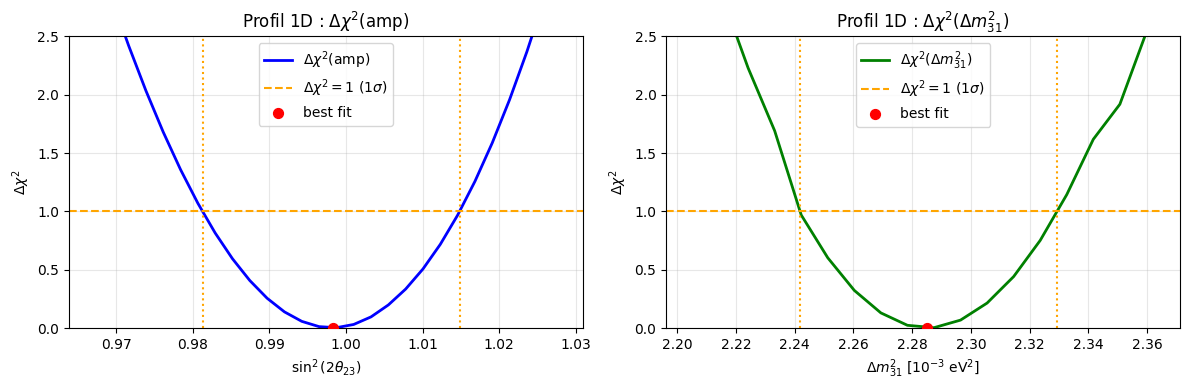

In [20]:
params_best = result.x
amp_best, dm31_best, mufrac_best = params_best
chi2_min_global = chi2(params_best)

print("=== BEST FIT GLOBAL ===")
print(f"amp       = {amp_best:.5f}")
print(f"dm31      = {dm31_best*1e3:.5f} x10^-3 eV^2")
print(f"mufrac    = {mufrac_best:.5f}")
print(f"chi2_min  = {chi2_min_global:.5f}")

n_amp = 200
n_dm31 = 200

amp_vals = np.linspace(BOUNDS[0][0], BOUNDS[0][1], n_amp)
dm31_vals = np.linspace(BOUNDS[1][0], BOUNDS[1][1], n_dm31)

chi2_grid = np.zeros((n_amp, n_dm31))
mufrac_grid = np.zeros((n_amp, n_dm31))

for i, amp in enumerate(amp_vals):
    for j, dm31 in enumerate(dm31_vals):

        def chi2_fixed_amp_dm31(x, amp=amp, dm31=dm31):
            mufrac = x[0]
            return chi2([amp, dm31, mufrac])

        res = minimize(
            chi2_fixed_amp_dm31,
            x0=[result.x[2]],
            bounds=[BOUNDS[2]],
            method="L-BFGS-B"
        )

        chi2_grid[i, j] = res.fun
        mufrac_grid[i, j] = res.x[0]

# Profils 1D
j_min_for_each_amp = np.argmin(chi2_grid, axis=1)
dm31_valley = dm31_vals[j_min_for_each_amp]
chi2_profile_amp = chi2_grid[np.arange(n_amp), j_min_for_each_amp]

i_min_for_each_dm31 = np.argmin(chi2_grid, axis=0)
amp_valley = amp_vals[i_min_for_each_dm31]
chi2_profile_dm31 = chi2_grid[i_min_for_each_dm31, np.arange(n_dm31)]

# Delta chi2 par rapport au minimum global
delta_chi2_amp = chi2_profile_amp - chi2_min_global
delta_chi2_dm31 = chi2_profile_dm31 - chi2_min_global

def get_1sigma_errors_delta(x_vals, delta_profile):
    """
    Retourne (x_best, err_low, err_high) en cherchant les points
    où delta_chi2 = 1, de chaque côté du minimum.
    """
    i_best = np.argmin(delta_profile)
    x_best = x_vals[i_best]

    err_low = np.nan
    for k in range(i_best, 0, -1):
        d0 = delta_profile[k-1]
        d1 = delta_profile[k]
        if (d0 - 1.0) * (d1 - 1.0) <= 0:
            x0, x1 = x_vals[k-1], x_vals[k]
            if d1 != d0:
                x_cross = x0 + (1.0 - d0) * (x1 - x0) / (d1 - d0)
                err_low = x_best - x_cross
            break

    err_high = np.nan
    for k in range(i_best, len(x_vals) - 1):
        d0 = delta_profile[k]
        d1 = delta_profile[k+1]
        if (d0 - 1.0) * (d1 - 1.0) <= 0:
            x0, x1 = x_vals[k], x_vals[k+1]
            if d1 != d0:
                x_cross = x0 + (1.0 - d0) * (x1 - x0) / (d1 - d0)
                err_high = x_cross - x_best
            break

    return x_best, err_low, err_high

amp_fit, amp_err_low, amp_err_high = get_1sigma_errors_delta(
    amp_vals, delta_chi2_amp
)

dm31_fit, dm31_err_low, dm31_err_high = get_1sigma_errors_delta(
    dm31_vals * 1e3, delta_chi2_dm31
)

AMP, DM31_MILLI = np.meshgrid(
    amp_vals,
    dm31_vals * 1e3,
    indexing="ij"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# --- amp ---
ax1.plot(amp_vals, delta_chi2_amp, 'b-', linewidth=2,
         label=r'$\Delta\chi^2(\mathrm{amp})$')
ax1.axhline(1, color='orange', linestyle='--', label=r'$\Delta\chi^2 = 1$ (1$\sigma$)')
ax1.axvline(amp_fit - amp_err_low, color='orange', linestyle=':')
ax1.axvline(amp_fit + amp_err_high, color='orange', linestyle=':')
ax1.scatter(amp_best, 0.0, color='red', s=50, zorder=5, label='best fit')
ax1.set_xlabel(r'$\sin^2(2\theta_{23})$')
ax1.set_ylabel(r'$\Delta\chi^2$')
ax1.set_title(r'Profil 1D : $\Delta\chi^2(\mathrm{amp})$')
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- dm31 ---
ax2.plot(dm31_vals * 1e3, delta_chi2_dm31, 'g-', linewidth=2,
         label=r'$\Delta\chi^2(\Delta m^2_{31})$')
ax2.axhline(1, color='orange', linestyle='--', label=r'$\Delta\chi^2 = 1$ (1$\sigma$)')
ax2.axvline(dm31_fit - dm31_err_low, color='orange', linestyle=':')
ax2.axvline(dm31_fit + dm31_err_high, color='orange', linestyle=':')
ax2.scatter(dm31_best * 1e3, 0.0, color='red', s=50, zorder=5, label='best fit')
ax2.set_xlabel(r'$\Delta m^2_{31}$ [$10^{-3}$ eV$^2$]')
ax2.set_ylabel(r'$\Delta\chi^2$')
ax2.set_title(r'Profil 1D : $\Delta\chi^2(\Delta m^2_{31})$')
ax2.grid(True, alpha=0.3)
ax2.legend()

ax1.set_xlim(amp_fit - 2*amp_err_low, amp_fit + 2*amp_err_high)
ax1.set_ylim(0, 2.5)

ax2.set_xlim(dm31_fit - 2*dm31_err_low, dm31_fit + 2*dm31_err_high)
ax2.set_ylim(0, 2.5)

plt.tight_layout()
plt.show()

In [23]:
print("=== BEST FIT GLOBAL ===")
print(f"amp      = {amp_best:.5f}")
print(f"dm31     = {dm31_best*1e3:.5f} x10^-3 eV^2")
print(f"mufrac   = {mufrac_best:.5f}")
print(f"chi2min  = {chi2_min_global:.5f}")

print("\n=== ERRORS FROM DELTA CHI2 = 1 ===")
print(f"amp      = {amp_fit:.5f} +{amp_err_high:.5f} / -{amp_err_low:.5f}")
print(f"dm31     = {dm31_fit:.5f} +{dm31_err_high:.5f} / -{dm31_err_low:.5f} x10^-3 eV^2")

=== BEST FIT GLOBAL ===
amp      = 0.99826
dm31     = 2.28519 x10^-3 eV^2
mufrac   = 0.04296
chi2min  = 360.63371

=== ERRORS FROM DELTA CHI2 = 1 ===
amp      = 0.99874 +0.01608 / -0.01747
dm31     = 2.28744 +0.04190 / -0.04561 x10^-3 eV^2


In [28]:
import numpy as np

amp = 0.8  # sin^2(2θ23)

s2_1 = (1 - np.sqrt(1 - amp)) / 2
s2_2 = (1 + np.sqrt(1 - amp)) / 2

print("sin^2(theta23) solution 1 =", s2_1)
print("sin^2(theta23) solution 2 =", s2_2)

sin^2(theta23) solution 1 = 0.27639320225002106
sin^2(theta23) solution 2 = 0.7236067977499789


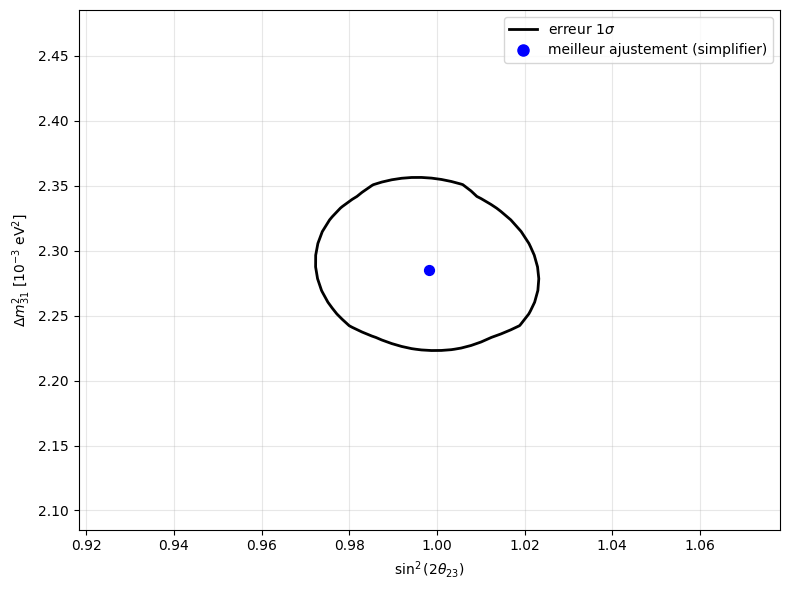

In [37]:
from matplotlib.lines import Line2D

delta_chi2_grid = chi2_grid - chi2_min_global

AMP, DM31_MILLI = np.meshgrid(
    amp_vals,
    dm31_vals * 1e3,
    indexing="ij"
)

plt.figure(figsize=(8, 6))

cs = plt.contour(
    AMP,
    DM31_MILLI,
    delta_chi2_grid,
    levels=[2.30],
    colors='black',
    linewidths=2,
)

# Best fit global
plt.scatter(
    amp_best,
    dm31_best * 1e3,
    color='blue',
    s=50,
    zorder=5
)

# Point externe
#plt.scatter(
    #1.0,
   # 2.34,
   # color='orange',
   # s=60,
   # zorder=6
#)

# Légende manuelle
contour_handle = Line2D(
    [0], [0],
    color='black',
    lw=2,
    label=r'erreur 1$\sigma$'
)

bestfit_handle = Line2D(
    [0], [0],
    marker='o',
    color='w',
    markerfacecolor='blue',
    markeredgecolor='blue',
    markersize=8,
    linestyle='None',
    label='meilleur ajustement (simplifier)'
)

#external_handle = Line2D(
  #  [0], [0],
   # marker='o',
    #color='w',
   # markerfacecolor='orange',
    #markeredgecolor='orange',
  #  markersize=8,
   # linestyle='None',
 #   label='Point externe'
#)

plt.xlabel(r'$\sin^2(2\theta_{23})$')
plt.ylabel(r'$\Delta m^2_{31}$ [$10^{-3}$ eV$^2$]')
#plt.title(r'Contour 2D à 1$\sigma$ : $\Delta\chi^2 = 2.30$')
plt.legend(handles=[contour_handle, bestfit_handle])
plt.grid(True, alpha=0.3)

plt.xlim(amp_best - 0.08, amp_best + 0.08)
plt.ylim(dm31_best * 1e3 - 0.2, dm31_best * 1e3 + 0.2)

plt.tight_layout()
plt.show()

=== SUPERPOSITION DES SURFACES ===
Aire surface fit        = 0.005250
Aire rectangle ref      = 0.056000
Aire intersection       = 0.000342
Fit couvert par référence   = 6.51 %
Référence couverte par fit  = 0.61 %
Overlap global (IoU)        = 0.56 %


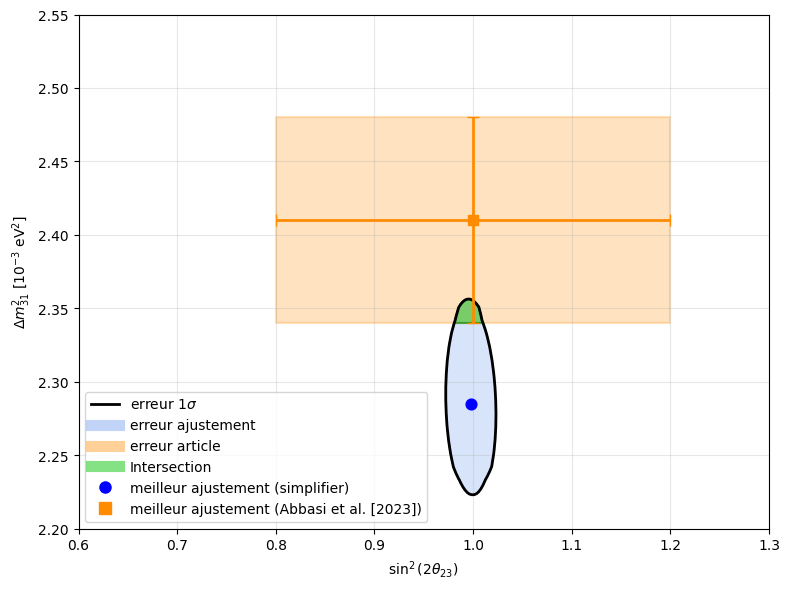

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import Polygon, MultiPolygon, box

# =========================================================
# 1) Surface Delta chi2
# =========================================================
delta_chi2_grid = chi2_grid - chi2_min_global

AMP, DM31_MILLI = np.meshgrid(
    amp_vals,
    dm31_vals * 1e3,
    indexing="ij"
)

fig, ax = plt.subplots(figsize=(8, 6))

# =========================================================
# 2) Contour 1 sigma de ta surface
# =========================================================
level_1sigma = 2.30
cs = ax.contour(
    AMP,
    DM31_MILLI,
    delta_chi2_grid,
    levels=[level_1sigma],
    colors='black',
    linewidths=2
)

# =========================================================
# 3) Extraire la région du contour
# =========================================================
contour_segments = cs.allsegs[0]

data_polygons = []
for seg in contour_segments:
    if len(seg) >= 3:
        poly = Polygon(seg)
        if poly.is_valid and poly.area > 0:
            data_polygons.append(poly)

if len(data_polygons) == 0:
    raise ValueError("Aucun contour fermé trouvé pour Delta chi2 = 2.30")

data_region = data_polygons[0]
for poly in data_polygons[1:]:
    data_region = data_region.union(poly)

# =========================================================
# 4) Région de référence RECTANGULAIRE
# =========================================================
x_ref = 1
y_ref = 2.41
sx_ref = 0.2
sy_ref = 0.07

ref_region = box(
    x_ref - sx_ref,
    y_ref - sy_ref,
    x_ref + sx_ref,
    y_ref + sy_ref
)

# =========================================================
# 5) Intersection et pourcentages
# =========================================================
intersection_region = data_region.intersection(ref_region)

area_data = data_region.area
area_ref = ref_region.area
area_inter = intersection_region.area
area_union = data_region.union(ref_region).area

percent_data_covered = 100.0 * area_inter / area_data if area_data > 0 else np.nan
percent_ref_covered = 100.0 * area_inter / area_ref if area_ref > 0 else np.nan
percent_iou = 100.0 * area_inter / area_union if area_union > 0 else np.nan

print("=== SUPERPOSITION DES SURFACES ===")
print(f"Aire surface fit        = {area_data:.6f}")
print(f"Aire rectangle ref      = {area_ref:.6f}")
print(f"Aire intersection       = {area_inter:.6f}")
print(f"Fit couvert par référence   = {percent_data_covered:.2f} %")
print(f"Référence couverte par fit  = {percent_ref_covered:.2f} %")
print(f"Overlap global (IoU)        = {percent_iou:.2f} %")

# =========================================================
# 6) Fonction d'affichage shapely -> matplotlib
# =========================================================
def add_shapely_polygon(ax, geom, **kwargs):
    if geom.is_empty:
        return

    if isinstance(geom, Polygon):
        x, y = geom.exterior.xy
        patch = MplPolygon(np.column_stack([x, y]), closed=True, **kwargs)
        ax.add_patch(patch)

    elif isinstance(geom, MultiPolygon):
        for g in geom.geoms:
            x, y = g.exterior.xy
            patch = MplPolygon(np.column_stack([x, y]), closed=True, **kwargs)
            ax.add_patch(patch)

# =========================================================
# 7) Tracé des zones
# =========================================================
add_shapely_polygon(
    ax, data_region,
    facecolor='cornflowerblue',
    edgecolor='black',
    alpha=0.25,
    linewidth=1.5
)

add_shapely_polygon(
    ax, ref_region,
    facecolor='darkorange',
    edgecolor='darkorange',
    alpha=0.25,
    linewidth=1.5
)

add_shapely_polygon(
    ax, intersection_region,
    facecolor='limegreen',
    edgecolor='green',
    alpha=0.60,
    linewidth=1.5
)

# =========================================================
# 8) Marqueurs
# =========================================================
ax.scatter(
    amp_best,
    dm31_best * 1e3,
    color='blue',
    s=60,
    zorder=5
)

ax.errorbar(
    x_ref, y_ref,
    xerr=sx_ref,
    yerr=sy_ref,
    fmt='s',
    color='darkorange',
    ecolor='darkorange',
    elinewidth=2,
    capsize=4,
    markersize=7,
    zorder=6
)

# =========================================================
# 9) Mise en forme
# =========================================================
ax.set_xlabel(r'$\sin^2(2\theta_{23})$')
ax.set_ylabel(r'$\Delta m^2_{31}$ [$10^{-3}$ eV$^2$]')
#ax.set_title(r'Superposition avec rectangle d’incertitude')
ax.grid(True, alpha=0.3)

ax.set_xlim(0.6, 1.3)
ax.set_ylim(2.2, 2.55)

legend_handles = [
    Line2D([0], [0], color='black', lw=2, label=r'erreur 1$\sigma$'),
    Line2D([0], [0], color='cornflowerblue', lw=8, alpha=0.4, label='erreur ajustement'),
    Line2D([0], [0], color='darkorange', lw=8, alpha=0.4, label='erreur article'),
    Line2D([0], [0], color='limegreen', lw=8, alpha=0.6, label='Intersection'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markeredgecolor='blue', markersize=8, linestyle='None',
           label='meilleur ajustement (simplifier) '),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='darkorange',
           markeredgecolor='darkorange', markersize=8, linestyle='None',
           label='meilleur ajustement (Abbasi et al. [2023])')
]

ax.legend(handles=legend_handles, loc='lower left')

plt.tight_layout()
plt.show()